# **SVM - Kernel comparison**

## Kernel interpretation

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn import svm
from sklearn.datasets import make_gaussian_quantiles

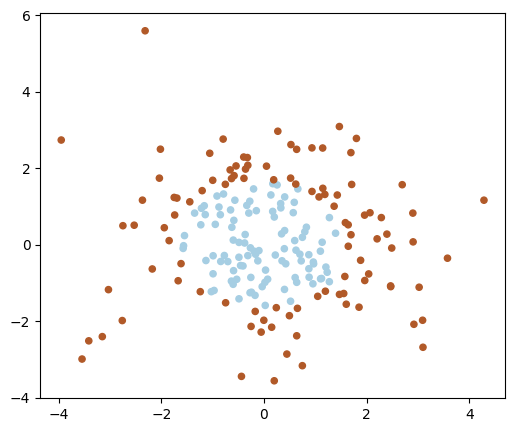

In [6]:
X, y = make_gaussian_quantiles(cov=2,
                                 n_samples = 300 , n_features = 2 ,
                                 n_classes = 2 , random_state = 1)
# Haremos un artificio  (modificacion a los datos para que se compacten y no se junten tanto)
X = np.vstack((X[y == 0][:100], X[y == 1][:100]))
y = np.hstack((y[y == 0][:100], y[y == 1][:100]))

#X=X[y == 0], y=y[y == 0], 0.5


_, ax = plt.subplots(figsize = (6,5))
plt.scatter( X[:, 0] , X[:,1] , c = y , s=20, cmap="Paired")

In [7]:
Xk= X[:, 0]**2 + X[:, 1]**2 # NUeva dimension cuadratica llamada kernel
#Xk = X[:, 0]*2 + X[:, 1]*2 # NUeva dimension lineal

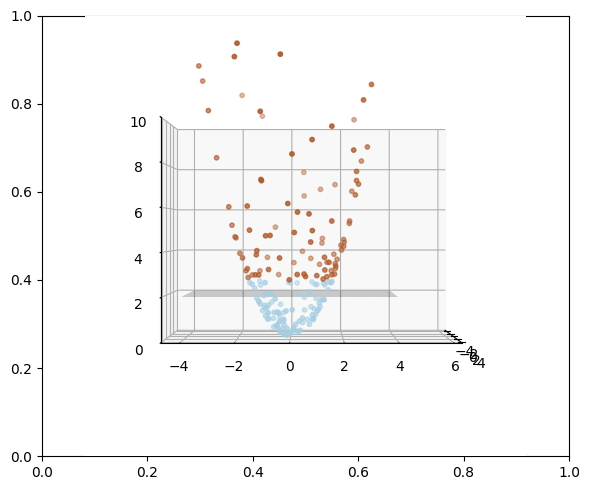

In [8]:
# crear un plot, crear figura
f, _ = plt.subplots(figsize = (6,5))
#para anadir el eje
ax = f.add_subplot(projection='3d')
ax.view_init(0, 0) # angulo de visualizacion
ax.scatter3D( X[:, 0] , X[:, 1] , Xk , c = y , s=10, cmap='Paired') # 3 dimensiones
ax.set_zlim(0, 20)

h_grid, v_grid =np.meshgrid(np.linspace(-4, 4, 10), np.linspace(-4, 4, 10))
#arreglo de constantes (de unos)
z_grid = np.ones(h_grid.shape)*2
#funcion para graficar planos
ax.plot_surface(h_grid, v_grid, z_grid, alpha = 0.2, color='k')
ax.set_zlim(0, 10)
plt.tight_layout()

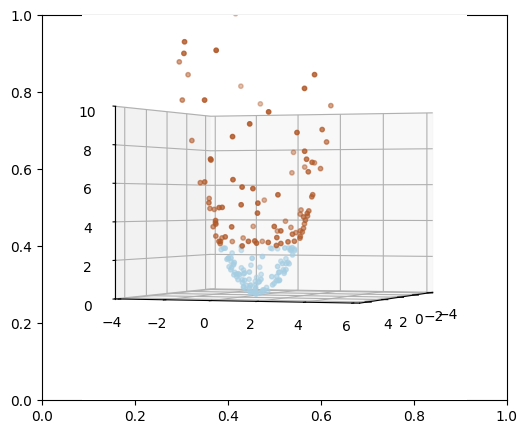

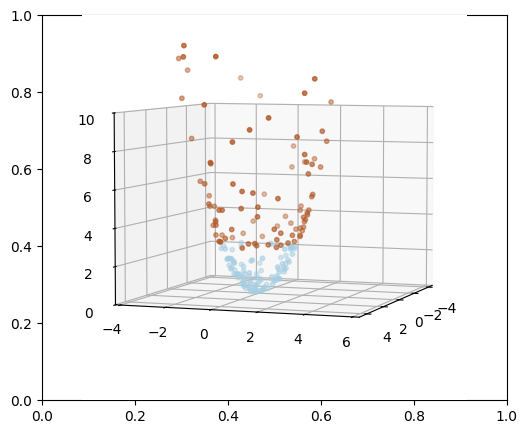

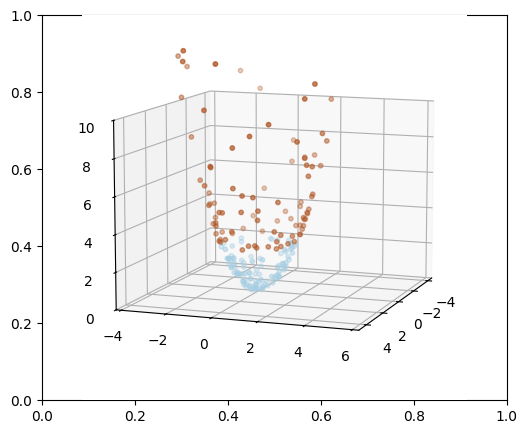

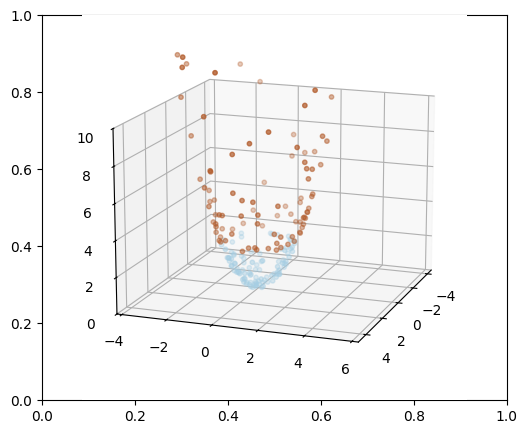

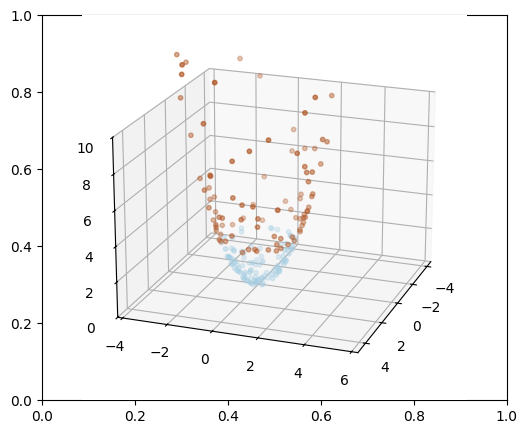

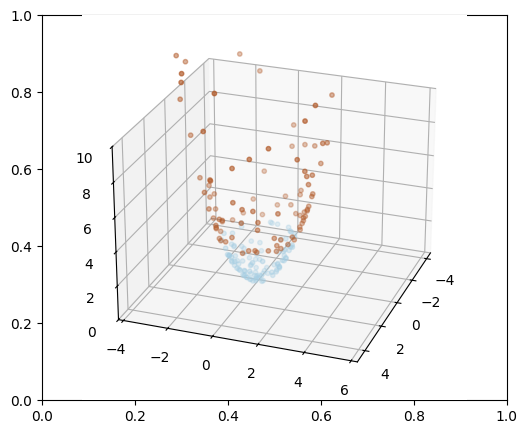

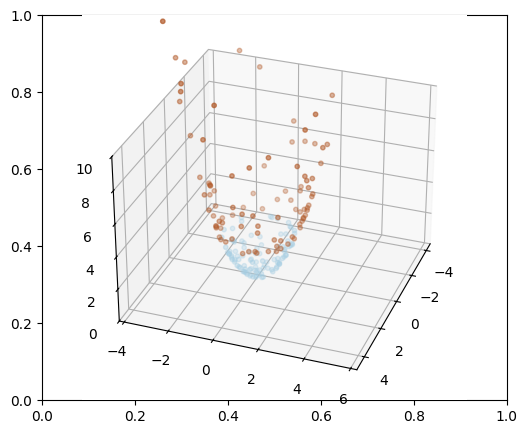

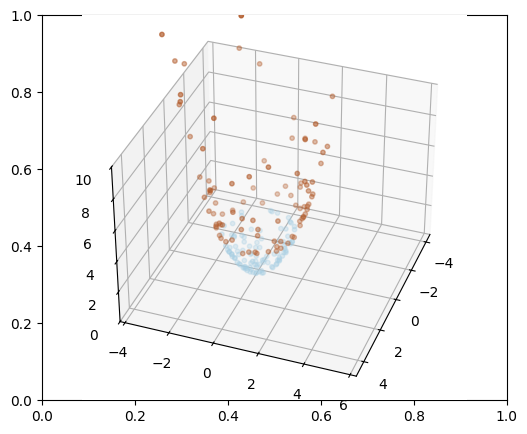

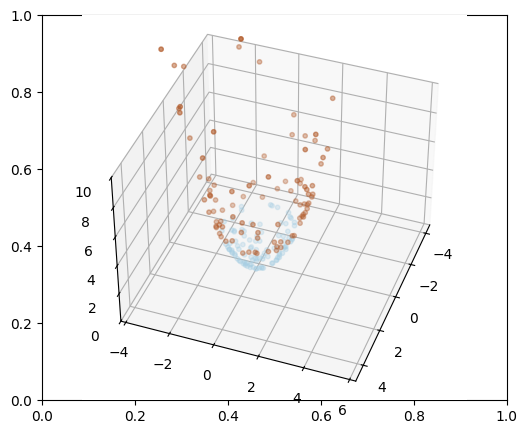

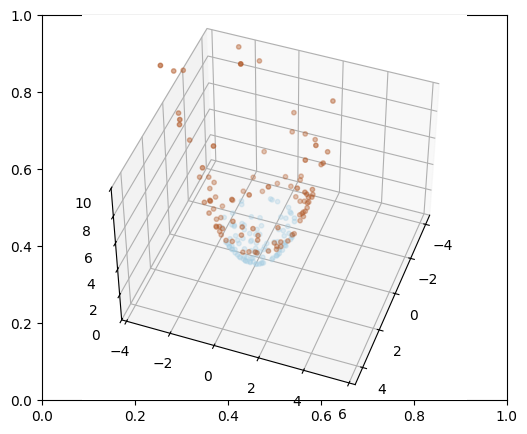

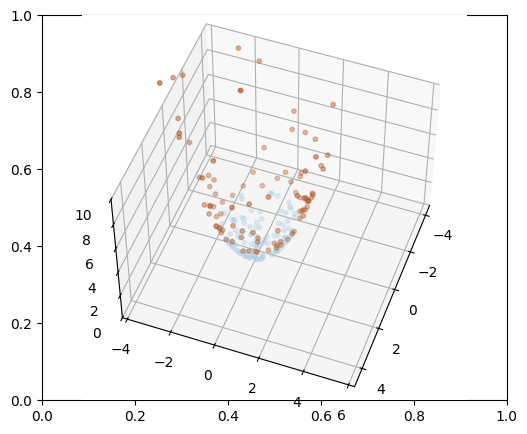

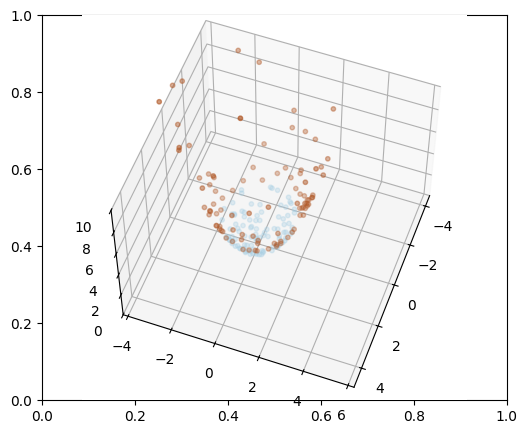

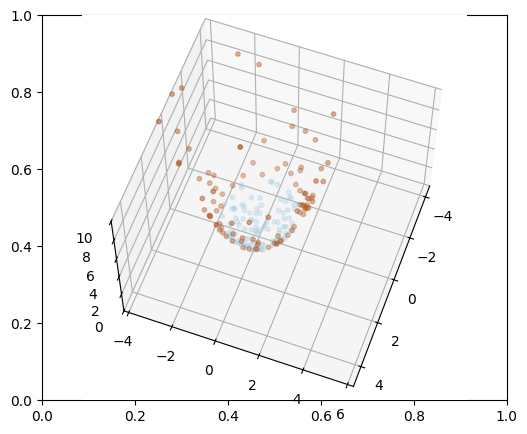

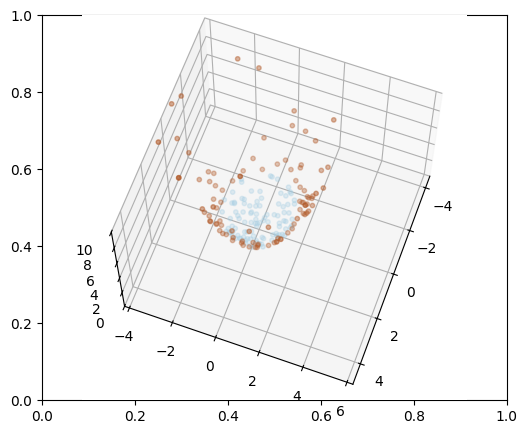

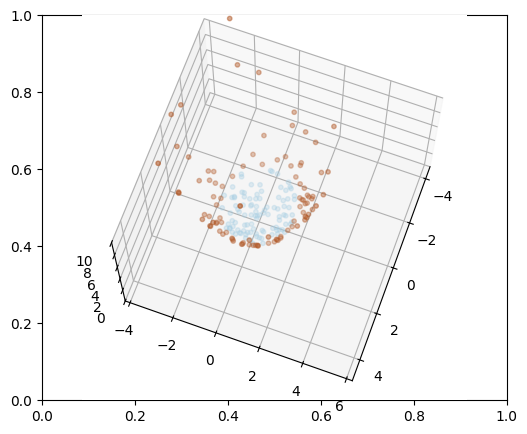

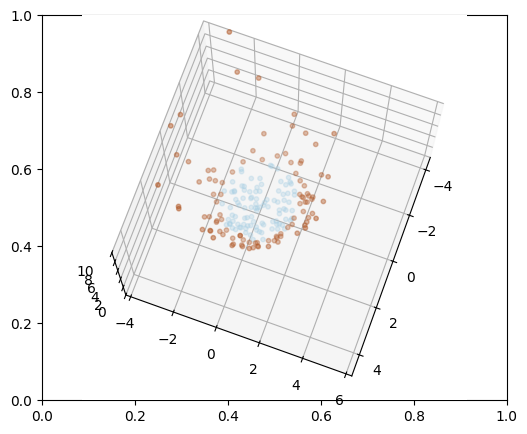

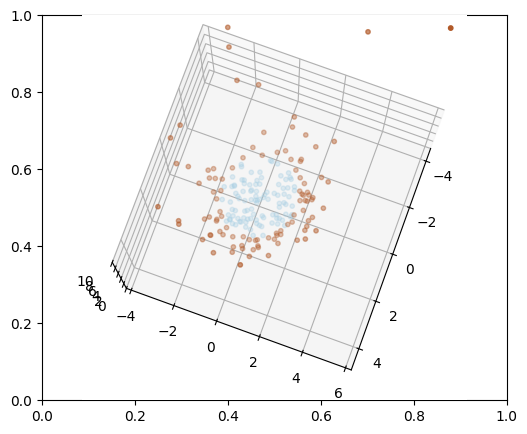

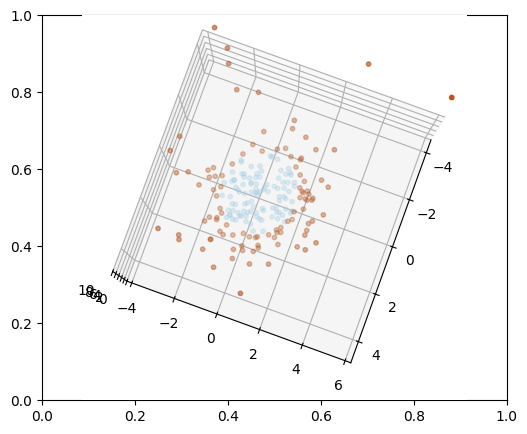

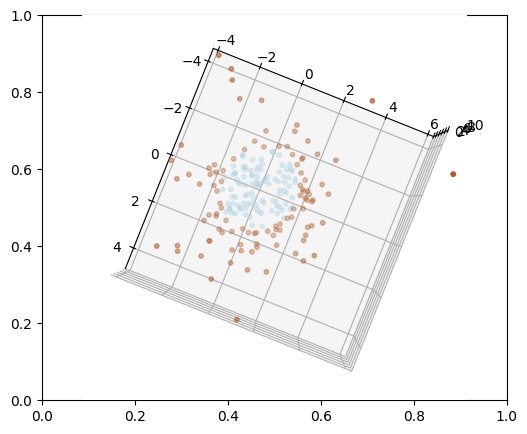

In [9]:
# Sve all figs
import os

os.makedirs('/content/drive/MyDrive/content/colab/images', exist_ok=True)
#exist true sirve para que no saque error si ya existe el folder que se va a crear
for a in range(0, 91, 5):
  # crear un plot, crear figura
  f, _ = plt.subplots(figsize = (6,5))
  #para anadir el eje
  ax = f.add_subplot(projection='3d')
  ax.view_init(a, 20) # angulo de visualizacion
  ax.scatter3D( X[:, 0] , X[:, 1] , Xk , c = y , s=10, cmap='Paired') # 3 dimensiones
  ax.set_zlim(0, 10)
  plt.savefig('/content/drive/MyDrive/content/colab/images/{0}.png'.format(a))

['45.png', '55.png', '40.png', '15.png', '20.png', '60.png', '80.png', '35.png', '85.png', '90.png', '65.png', '25.png', '75.png', '0.png', '70.png', '10.png', '5.png', '50.png', '30.png']


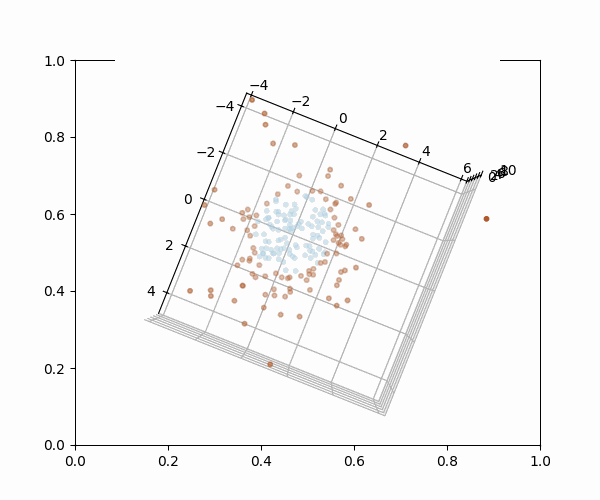

In [10]:
import os
from PIL import Image as PILImage #gestion de archivos del sistema, escanear dir
from natsort import natsorted, ns #ordenar archivos
from IPython.display import Image

# Save a gif
list_imgs = []

print(os.listdir('/content/drive/MyDrive/content/colab/images/'))
for file_ in natsorted(os.listdir('/content/drive/MyDrive/content/colab/images/'), alg=ns.PATH, key=lambda y: y.lower()): #LISTA ORDENADA
  image = PILImage.open("/content/drive/MyDrive/content/colab/images/" + format(file_))
  list_imgs.append(image)
image.save("kernel_.gif", save_all=True, append_images = list_imgs, duration=200, loop=0)
Image('kernel_.gif')

## SVM

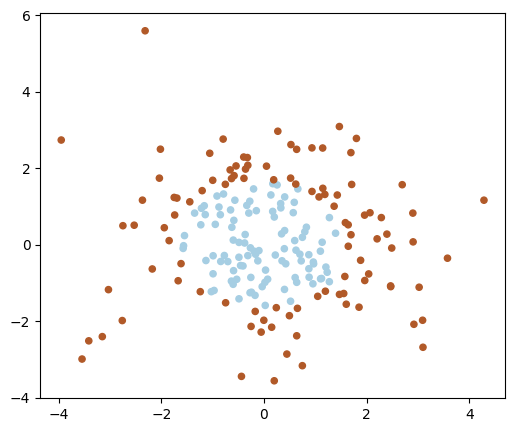

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_classification

In [12]:
clf = svm.SVC(kernel = 'linear')
clf.fit(X , y)

SVC(kernel='linear')

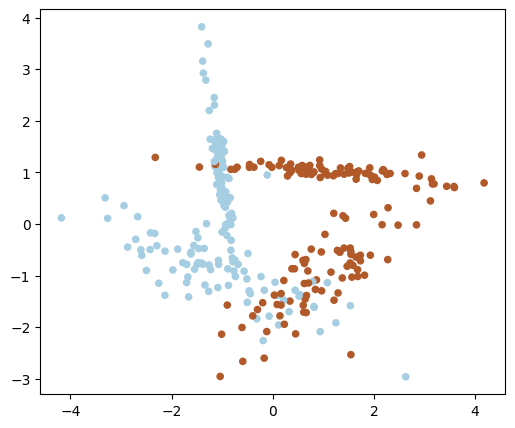

In [13]:
# we create 100 separable points
X, y = make_classification(n_samples = 300 , n_features=2, n_redundant=0, n_informative=2, n_clusters_per_class=2, random_state=2)
_, ax = plt.subplots(figsize = (6,5))
plt.scatter( X[:, 0] , X[:,1] , c = y , s=20, cmap="Paired")

In [12]:

kernels = ['linear', 'poly', 'rbf', 'sigmoid'] #DEfinir linea de kernels

_, axes = plt.subplots(1,4, figsize = (20,5)) #5x5 cada cuadricula

# fit the model
for _ :
    #
    clf = svm.SVC(kernel = _ , gamma = 1)
    clf.fit( _ , _ )

    x_min, x_max = _ , _
    y_min, y_max = _ , _

    x_dim, y_dim = np.meshgrid(np.arange( _ , _ , 0.01), np.arange( _ , _ , 0.01))
    predictions = clf.predict(np.c_[x_dim.ravel(), y_dim.ravel()])

    predictions = predictions.reshape( _ )
    axes[i].pcolormesh( _ , _ , predictions, cmap = plt.cm.Paired)
    axes[i].contour( _ , _ , predictions, colors=['k', 'k'], linestyles=['-', '-'], levels=[0, 1])

    axes[i].scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s = 90, facecolors = 'none', edgecolors = 'k')

    axes[i].scatter( _ , _ , c = _ , cmap=plt.cm.Paired, edgecolors='k')
    axes[i].set_axis_off()

plt.show()

SyntaxError: invalid syntax (ipython-input-3980581975.py, line 6)

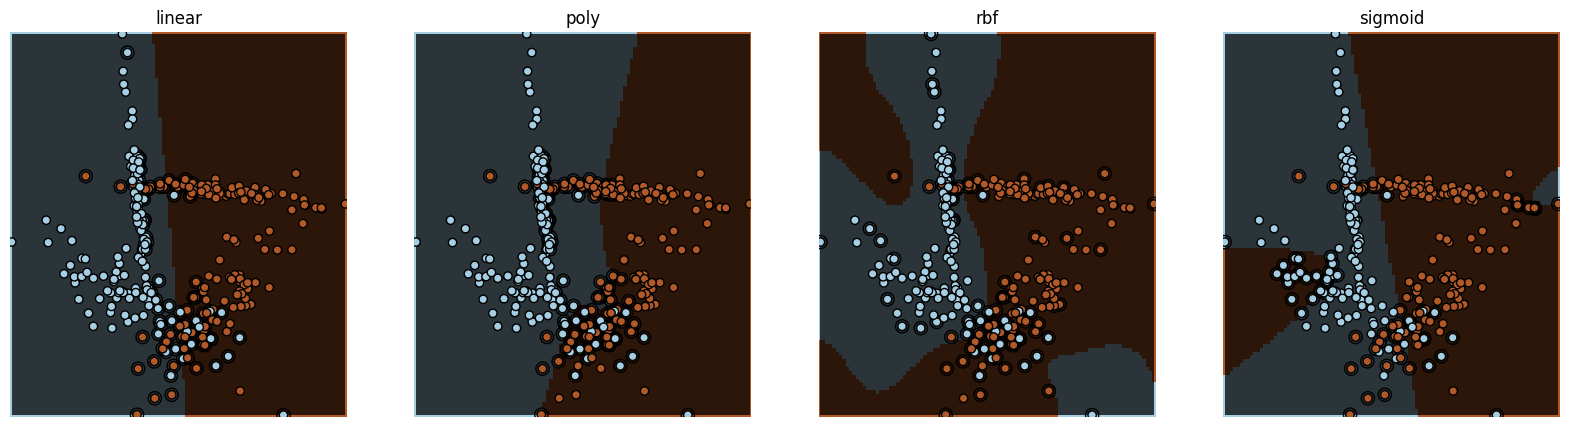

In [18]:

kernels = ['linear', 'poly', 'rbf', 'sigmoid']

_, axes = plt.subplots(1,4, figsize = (20,5))

# fit the model
for i, kernel in enumerate(kernels):
    #
    clf = svm.SVC(kernel = kernel , gamma = 1)
    clf.fit( X , y )

#Grafico fronteras de decision
    h_min, h_max = X[:, 0].min() , X[:, 0].max()
    v_min, v_max = X[:, 1].min() , X[:, 1].max()

    h_grid, v_grid = np.meshgrid(np.linspace( h_min , h_max , 100), np.linspace( v_min , v_max , 100))
    predictions = clf.predict(np.c_[h_grid.ravel(), v_grid.ravel()])

    predictions = predictions.reshape(h_grid.shape)
    axes[i].pcolormesh( h_grid , v_grid , predictions, cmap = 'Paired')
    axes[i].contourf( h_grid , v_grid , predictions, colors=['k', 'k'], alpha = 0.75, linestyles=['-', '-'], levels=[0,1])

    axes[i].scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s = 90, facecolors = 'none', edgecolors = 'k')

    axes[i].scatter( X[:, 0] , X[:, 1] , c=y, cmap='Paired', edgecolors='k')
    axes[i].set_title(kernel)
    axes[i].set_axis_off()

plt.show()

Create a function that plots the decision boundaries of a given SVM

## In real data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Evaluate the different SVM kernels in the Iris and Fruits datasets